In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error


### 1. Loading data

In [2]:
df = pd.read_csv('../data/data.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

### 2. data Cleaning

In [3]:
df_cleaned = df.drop(['date', 'street', 'city', 'statezip', 'country'], axis=1)
print(df_cleaned.to_string())

             price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  yr_renovated
0     3.130000e+05       3.0       1.50         1340      7912     1.5           0     0          3        1340              0      1955          2005
1     2.384000e+06       5.0       2.50         3650      9050     2.0           0     4          5        3370            280      1921             0
2     3.420000e+05       3.0       2.00         1930     11947     1.0           0     0          4        1930              0      1966             0
3     4.200000e+05       3.0       2.25         2000      8030     1.0           0     0          4        1000           1000      1963             0
4     5.500000e+05       4.0       2.50         1940     10500     1.0           0     0          4        1140            800      1976          1992
5     4.900000e+05       2.0       1.00          880      6380     1.0           0     0      

### 3. Understanding the data - Visualising

Average price of the house : 551962.99


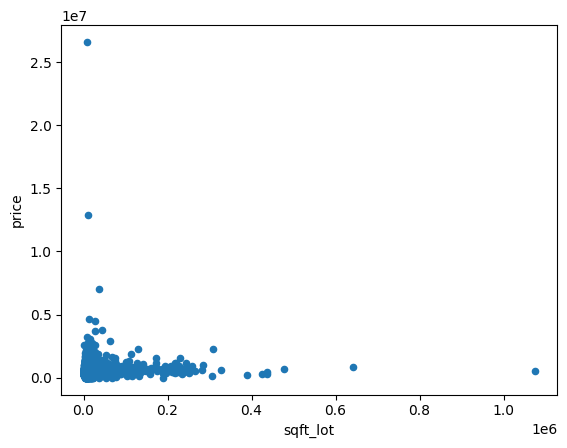

In [4]:
df.plot(kind="scatter",x="sqft_lot",y="price")

avg_price = df["price"].mean()
print(f"Average price of the house : {avg_price:.2f}")

### 4. Preparing Training and Testing Data

In [5]:
Train = df_cleaned.sample(frac=0.8, random_state=42)
Test = df_cleaned.drop(Train.index)

print(Train.shape)
print(Test.shape)


X_train = Train.drop("price",axis=1)
Y_train = Train["price"]
print(X_train.shape)
print(Y_train.shape)


X_test = Test.drop("price",axis=1)
Y_test = Test["price"]
print(X_test.shape)
print(Y_test.shape)


(3680, 13)
(920, 13)
(3680, 12)
(3680,)
(920, 12)
(920,)


### 5. Normalisation  - Feature Scaling

In [6]:
scalar = StandardScaler()
X_train_norm = scalar.fit_transform(X_train)
print(f"peak to peak range (without normalization): {np.ptp(X_train,axis=0)}")
print(f"peak to peak range (with normalization): {np.ptp(X_train_norm,axis=0)}")

peak to peak range (without normalization): bedrooms               7.0
bathrooms              8.0
sqft_living        13170.0
sqft_lot         1073580.0
floors                 2.5
waterfront             1.0
view                   4.0
condition              4.0
sqft_above          9040.0
sqft_basement       4820.0
yr_built             114.0
yr_renovated        2014.0
dtype: float64
peak to peak range (with normalization): [ 7.72878297 10.1079691  13.60842317 29.27584254  4.62026401 12.17402316
  5.06904394  5.90047499 10.48805026 10.33009041  3.83805716  2.05621556]


### 6. Model Training

In [7]:
sgdr = SGDRegressor(max_iter=10000)
sgdr.fit(X_train_norm,Y_train)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

number of iterations completed: 22, number of weight updates: 80961.0


In [8]:
w_norm = sgdr.coef_
b_norm = sgdr.intercept_
print(f"model parameters:  \nw: {w_norm},\n\n b:{b_norm}")

model parameters:  
w: [-49752.97172263  53009.58302532 118136.23930279 -22041.10029597
  27228.4863406   17355.16286956  46846.42037778  18540.39794334
 107139.42385669  47113.78356098 -71343.19517092   8817.7902995 ],

 b:[552528.81132417]


In [9]:
## normalise Training data
# dont do fit_transform, it is only applied to training data and the sigma and mu of it is used in the test data


X_test_norm = scalar.transform(X_test)

pred = sgdr.predict(X_test_norm)

In [10]:
np.set_printoptions(precision=2)
print(f"Predicted Values :\n{pred[:10]}")
print(f"Target Values :\n{Y_test[:10].to_string(index=False)}")

Predicted Values :
[517600.6  454519.19 287847.12 411235.1  402369.54 668131.82 829860.12
 414510.26 279007.01 482675.19]
Target Values :
420000.0
550000.0
490000.0
640000.0
419000.0
698000.0
400000.0
335000.0
308500.0
407500.0


In [13]:
mse = mean_squared_error(Y_test,pred)
root_mse = np.sqrt(mse)
print(f"Average price of house : {avg_price:.2f}")
print(f"MSE : {root_mse:.2f}")

Average price of house : 551962.99
MSE : 265516.49
